# 🦍 Notebook 04 — Intergroup Spatial Dynamics
Analyzes spatial relationships between gorilla groups:
- Pairwise distances between simultaneously-followed groups
- Daily minimum inter-group distances
- Distance matrix
- Spatial overlap (Bhattacharyya coefficient)
- Encounter frequency analysis
- Temporal patterns in separation


## Cell 1 — Imports & Load Data

In [2]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

project_root = os.path.abspath('..')
sys.path.insert(0, project_root)
from src.intergroup_analysis import (
    pairwise_distances_by_timestamp,
    daily_min_intergroup_distance,
    intergroup_distance_matrix,
    spatial_overlap_bhattacharyya,
    overlap_matrix,
    encounter_frequency
)

DATA_PATH = os.path.join(project_root, 'data', 'processed', 'gorilla_gps_clean.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp','date'])
GROUPS = sorted(df['group_id'].unique())
COLORS = {'Susa':'#2E86AB','Hirwa':'#A23B72','Amahoro':'#F18F01',
          'Umubano':'#C73E1D','Pablo':'#3B1F2B','Kwitonda':'#44BBA4'}
print(f'Loaded: {len(df):,} fixes, {len(GROUPS)} groups')

Loaded: 105,143 fixes, 6 groups


## Cell 2 — Compute Pairwise Distances


In [3]:
print('Computing pairwise distances between all group pairs...')
print('(This may take a few minutes...)')

# Use a monthly subsample for speed during development
# Remove the sample() call to use the full dataset
pairwise_df = pairwise_distances_by_timestamp(df)

print(f'\nPairwise distance records: {len(pairwise_df):,}')
print(f'Group pairs analysed: {pairwise_df[["group_a","group_b"]].drop_duplicates().shape[0]}')
print(pairwise_df.head())

# Save
pairwise_path = os.path.join(project_root,'data','processed','pairwise_distances.csv')
pairwise_df.to_csv(pairwise_path, index=False)
print(f'\n✅ Saved to {pairwise_path}')

Computing pairwise distances between all group pairs...
(This may take a few minutes...)

Pairwise distance records: 257,564
Group pairs analysed: 15
            timestamp  group_a group_b  distance_km
0 2022-01-01 06:10:00  Amahoro   Hirwa     2.822747
1 2022-01-01 06:20:00  Amahoro   Hirwa     2.846146
2 2022-01-01 06:30:00  Amahoro   Hirwa     2.857009
3 2022-01-01 06:40:00  Amahoro   Hirwa     2.873074
4 2022-01-01 06:50:00  Amahoro   Hirwa     2.869885

✅ Saved to c:\Users\User\Desktop\gorilla-movement-ecology\data\processed\pairwise_distances.csv


## Cell 3 — Daily Minimum Inter-Group Distances

In [4]:
daily_min_df = daily_min_intergroup_distance(pairwise_df)

print('Daily minimum distance summary (km):')
print(daily_min_df.groupby(['group_a','group_b'])['min_distance_km'].describe().round(3))

daily_min_df.to_csv(
    os.path.join(project_root,'data','processed','daily_min_distances.csv'), index=False)
print('\n✅ Saved')

Daily minimum distance summary (km):
                   count   mean    std    min    25%    50%    75%     max
group_a  group_b                                                          
Amahoro  Hirwa     365.0  3.094  0.868  1.256  2.490  3.124  3.666   5.133
         Kwitonda  365.0  4.265  1.013  1.193  3.620  4.239  4.950   7.604
         Pablo     365.0  1.748  0.768  0.017  1.147  1.845  2.304   4.134
         Susa      365.0  6.078  1.201  3.275  5.277  6.036  6.831   9.232
         Umubano   365.0  3.815  0.943  1.363  3.222  3.807  4.322   6.381
Hirwa    Kwitonda  365.0  4.436  0.960  2.467  3.747  4.389  5.063   7.351
         Pablo     365.0  2.903  1.006  0.891  2.080  2.941  3.699   5.479
         Susa      365.0  3.109  1.180  0.521  2.330  3.111  3.909   5.977
         Umubano   365.0  4.250  0.843  2.530  3.587  4.178  4.847   6.624
Kwitonda Pablo     365.0  2.728  0.955  0.042  2.005  2.783  3.516   5.113
         Susa      365.0  7.159  1.218  4.490  6.187  7.254  7.

## Cell 4 — Distance Matrix

Mean Daily Minimum Distance Matrix (km):
          Amahoro  Hirwa  Kwitonda  Pablo  Susa  Umubano
Amahoro      0.00   3.09      4.27   1.75  6.08     3.82
Hirwa        3.09   0.00      4.44   2.90  3.11     4.25
Kwitonda     4.27   4.44      0.00   2.73  7.16     7.85
Pablo        1.75   2.90      2.73   0.00  6.09     5.21
Susa         6.08   3.11      7.16   6.09  0.00     5.37
Umubano      3.82   4.25      7.85   5.21  5.37     0.00


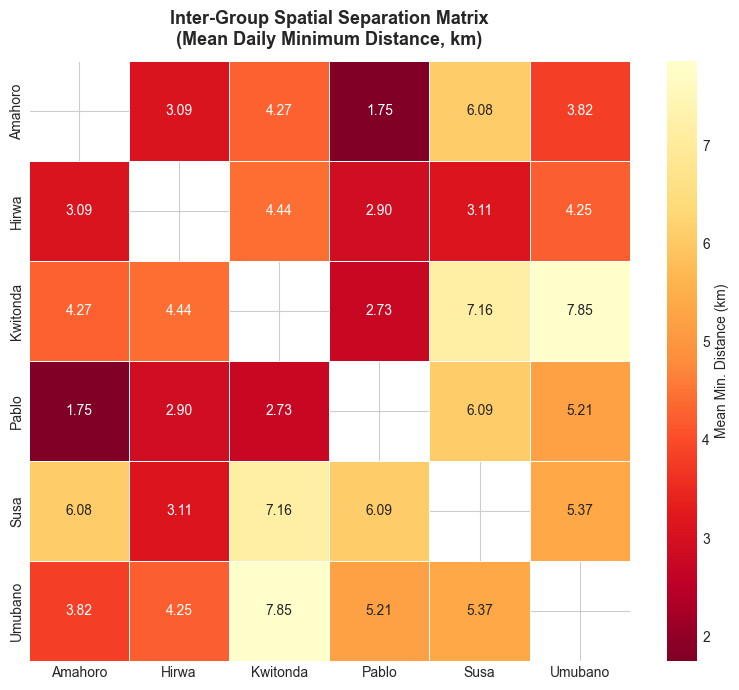

In [5]:
dist_matrix = intergroup_distance_matrix(daily_min_df)
print('Mean Daily Minimum Distance Matrix (km):')
print(dist_matrix.round(2))

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.eye(len(dist_matrix), dtype=bool)
values = dist_matrix.values.copy()
values[mask] = np.nan
sns.heatmap(values, annot=True, fmt='.2f', cmap='YlOrRd_r',
            xticklabels=dist_matrix.columns, yticklabels=dist_matrix.index,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label':'Mean Min. Distance (km)'})
ax.set_title('Inter-Group Spatial Separation Matrix\n(Mean Daily Minimum Distance, km)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','04_distance_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Distance Time Series

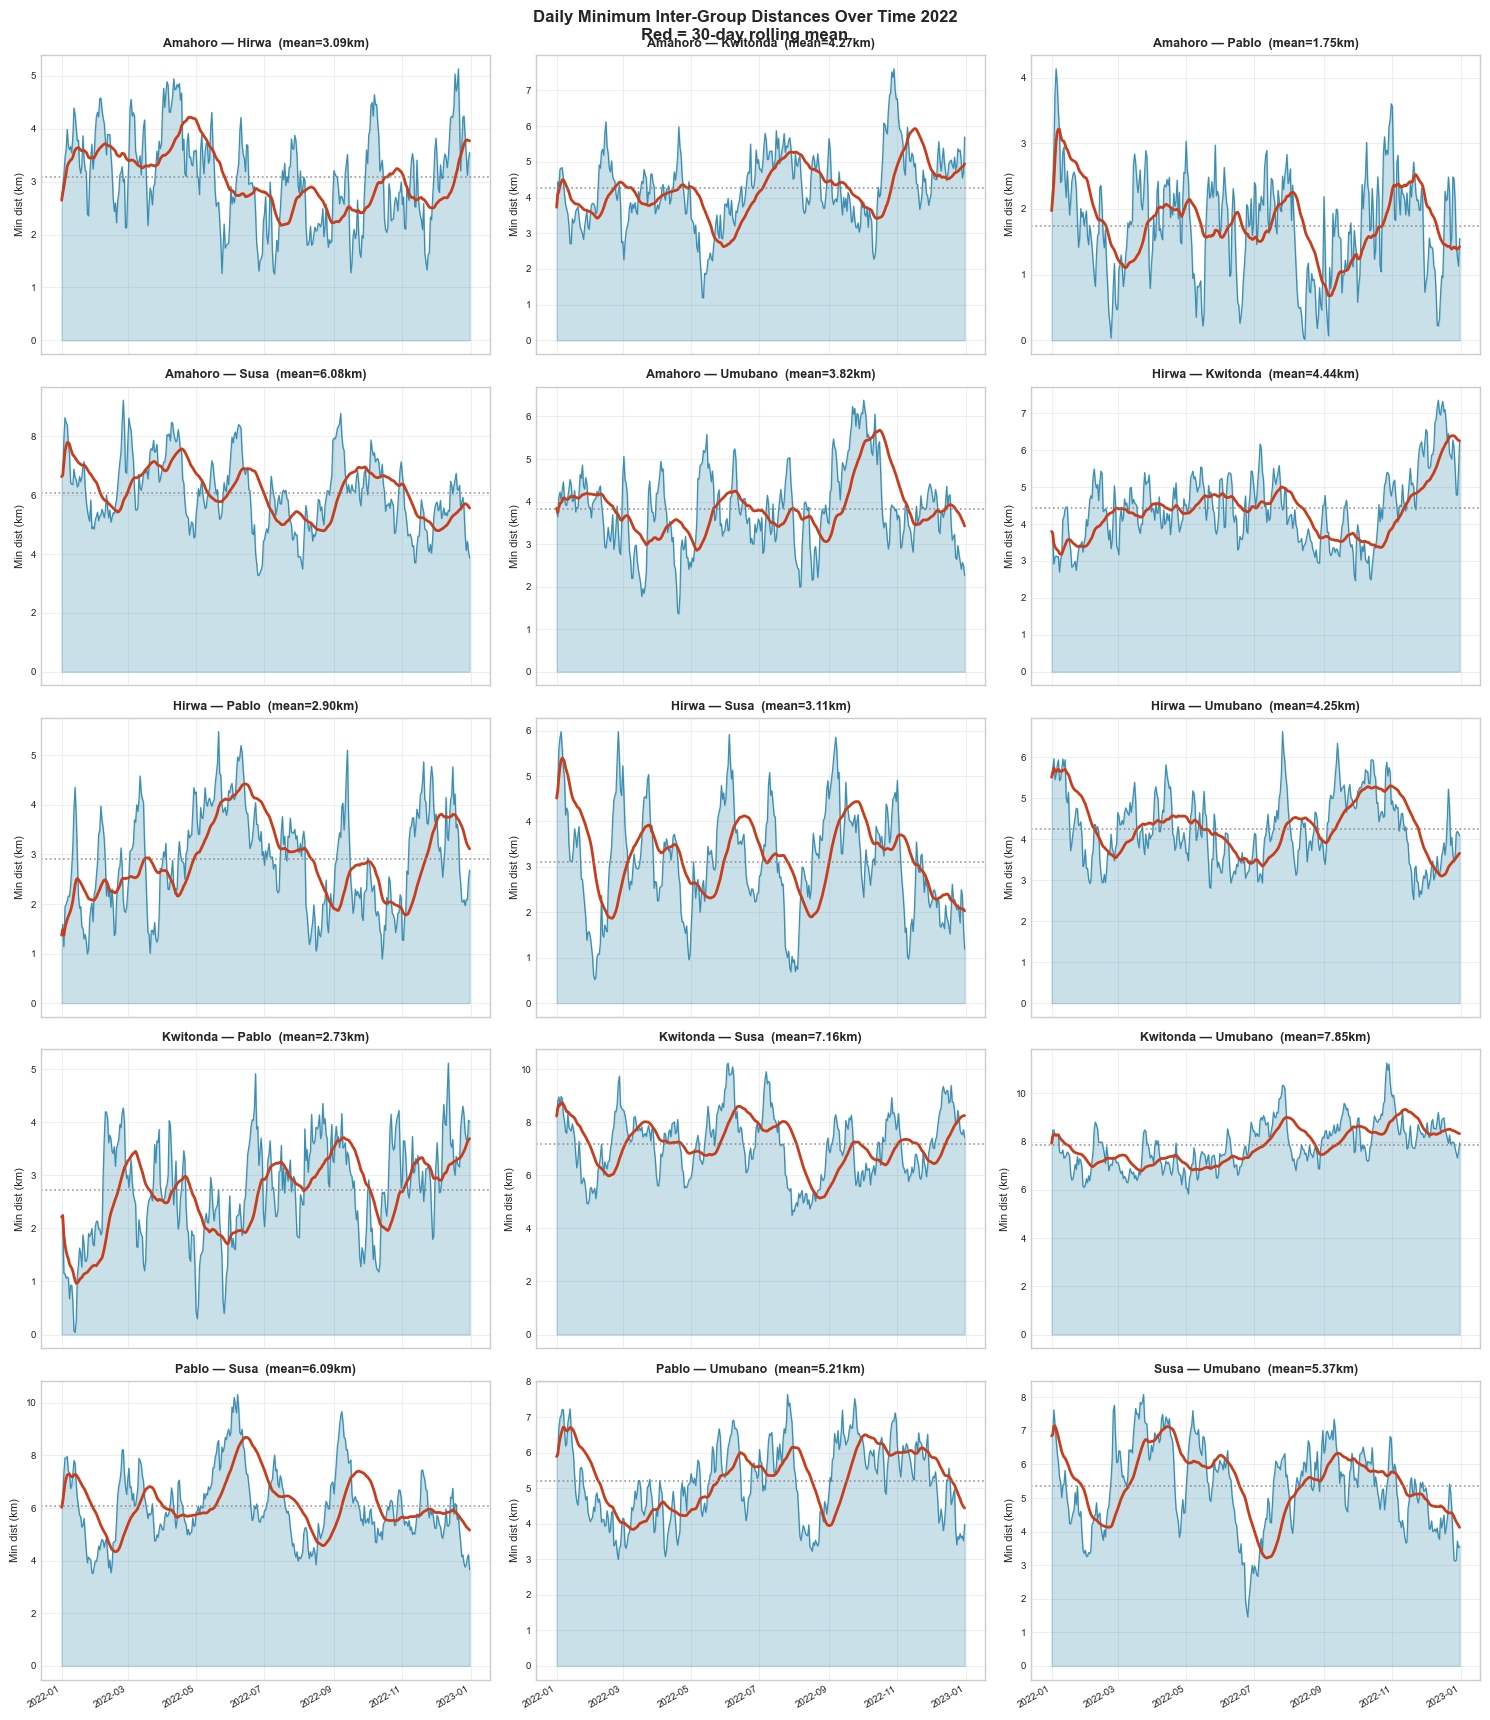

In [6]:
all_pairs = daily_min_df[['group_a','group_b']].drop_duplicates().values.tolist()
n_pairs = len(all_pairs)
n_cols = 3
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*3.5), sharex=True)
axes = axes.flatten()

for i, (ga, gb) in enumerate(all_pairs):
    sub = daily_min_df[
        (daily_min_df['group_a']==ga) & (daily_min_df['group_b']==gb)
    ].copy()
    sub['date'] = pd.to_datetime(sub['date'])
    sub = sub.sort_values('date')

    ax = axes[i]
    ax.fill_between(sub['date'], sub['min_distance_km'], alpha=0.25, color='#2E86AB')
    ax.plot(sub['date'], sub['min_distance_km'], color='#2E86AB', linewidth=0.9, alpha=0.9)

    # Rolling 30-day mean
    rolling = sub.set_index('date')['min_distance_km'].rolling('30D').mean()
    ax.plot(rolling.index, rolling.values, color='#C73E1D', linewidth=2, label='30d mean')

    mean_d = sub['min_distance_km'].mean()
    ax.axhline(mean_d, color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
    ax.set_title(f'{ga} — {gb}  (mean={mean_d:.2f}km)', fontsize=9, fontweight='bold')
    ax.set_ylabel('Min dist (km)', fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Daily Minimum Inter-Group Distances Over Time 2022\nRed = 30-day rolling mean',
             fontsize=12, fontweight='bold')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','04_distance_timeseries.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Spatial Overlap (Bhattacharyya Coefficient)

Computing spatial overlap matrix (Bhattacharyya coefficient)...
(Takes ~2-3 minutes)

Bhattacharyya Coefficient Matrix (0=no overlap, 1=complete overlap):
          Amahoro  Hirwa  Kwitonda  Pablo   Susa  Umubano
Amahoro     1.000  0.306     0.180  0.835  0.000    0.018
Hirwa       0.306  1.000     0.000  0.099  0.082    0.438
Kwitonda    0.180  0.000     1.000  0.505  0.000    0.000
Pablo       0.835  0.099     0.505  1.000  0.000    0.001
Susa        0.000  0.082     0.000  0.000  1.000    0.623
Umubano     0.018  0.438     0.000  0.001  0.623    1.000


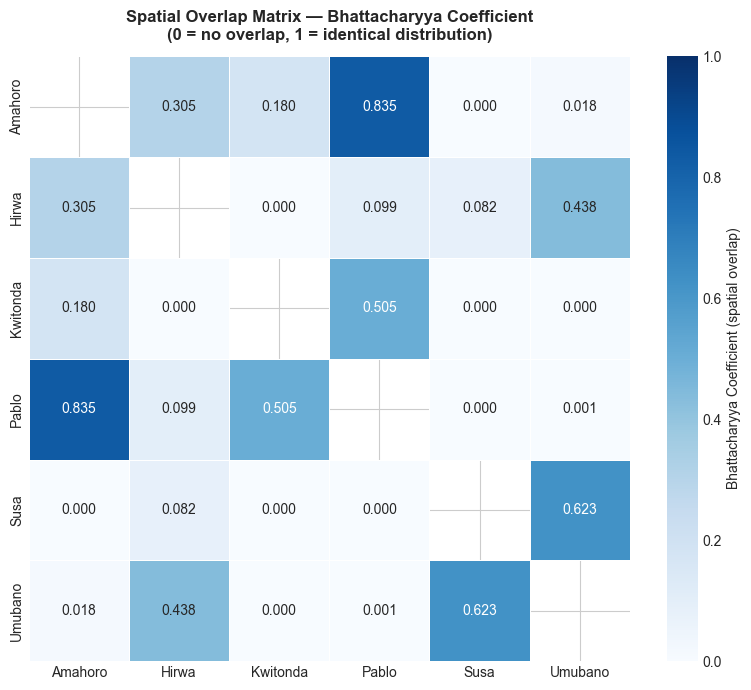

In [7]:
print('Computing spatial overlap matrix (Bhattacharyya coefficient)...')
print('(Takes ~2-3 minutes)')

bc_matrix = overlap_matrix(df)

print('\nBhattacharyya Coefficient Matrix (0=no overlap, 1=complete overlap):')
print(bc_matrix.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.eye(len(bc_matrix), dtype=bool)
vals = bc_matrix.values.copy().astype(float)
vals[mask] = np.nan
sns.heatmap(vals, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=bc_matrix.columns, yticklabels=bc_matrix.index,
            linewidths=0.5, linecolor='white', ax=ax, vmin=0, vmax=1,
            cbar_kws={'label':'Bhattacharyya Coefficient (spatial overlap)'})
ax.set_title('Spatial Overlap Matrix — Bhattacharyya Coefficient\n'
             '(0 = no overlap, 1 = identical distribution)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','04_overlap_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — Encounter Frequency Analysis

In [8]:
# Count close-approach events (< 500m threshold)
encounters = encounter_frequency(pairwise_df, threshold_km=0.5)
if len(encounters) > 0:
    print('Encounter events (within 500m):')
    print(encounters.sort_values('n_encounters', ascending=False).to_string(index=False))
else:
    print('No encounters detected at 500m threshold')
    print('Testing at 1.0km threshold...')
    encounters = encounter_frequency(pairwise_df, threshold_km=1.0)
    print(encounters.sort_values('n_encounters', ascending=False).to_string(index=False))

print(f'\nMean separation strongly > encounter threshold')
print(f'→ Confirms active spatial avoidance behavior')

Encounter events (within 500m):
 group_a group_b  n_encounters  rate_per_day
 Amahoro   Pablo           488        1.3370
Kwitonda   Pablo           112        0.3068

Mean separation strongly > encounter threshold
→ Confirms active spatial avoidance behavior


## Cell 8 — Distance Distribution by Season

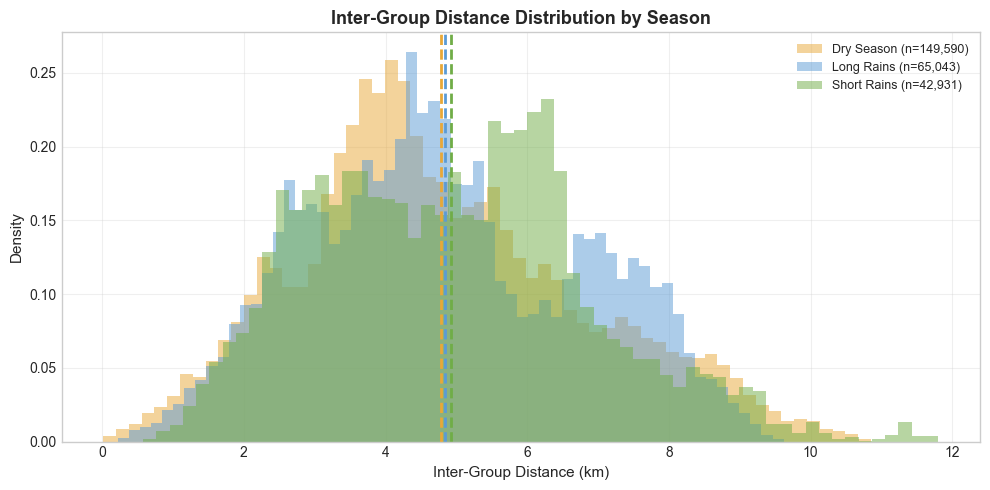

In [9]:
pairwise_df2 = pairwise_df.copy()
pairwise_df2['date'] = pd.to_datetime(pairwise_df2['timestamp']).dt.date
pairwise_df2['month'] = pd.to_datetime(pairwise_df2['timestamp']).dt.month

def month_to_season(m):
    if m in [6,7,8]: return 'Dry Season'
    elif m in [3,4,5]: return 'Long Rains'
    elif m in [10,11]: return 'Short Rains'
    else: return 'Dry Season'

pairwise_df2['season'] = pairwise_df2['month'].apply(month_to_season)

fig, ax = plt.subplots(figsize=(10, 5))
s_colors = {'Dry Season':'#E8A838','Long Rains':'#5B9BD5','Short Rains':'#70AD47'}
for season, color in s_colors.items():
    data = pairwise_df2[pairwise_df2['season']==season]['distance_km'].dropna()
    data.hist(bins=60, ax=ax, color=color, alpha=0.5,
              density=True, label=f'{season} (n={len(data):,})')
    ax.axvline(data.mean(), color=color, linewidth=2, linestyle='--')

ax.set_xlabel('Inter-Group Distance (km)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Inter-Group Distance Distribution by Season', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','04_seasonal_distances.png'),
            dpi=150, bbox_inches='tight')
plt.show()